# Assignment 4: Customer Segmentation with Clustering

**Student Name:** Reagan

**Date:** 2/17/26

---

## Assignment Overview

You've been hired as a data science consultant by a UK-based online gift retailer. They're spending the same amount on marketing to all customers regardless of value. Your task: segment their customer base using transaction data from 2009-2011, identify distinct customer groups, and provide actionable recommendations for each segment.

---

## Step 1: Import Libraries and Load Data

In [ ]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [4]:
# Load the Online Retail II dataset
# TODO: Load online_retail_II.csv from the data folder

df = pd.read_csv("data/online_retail_II.csv")

# Display basic information
# TODO: Display the first few rows and basic info about the dataset

df.head()
df.info()

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Dataset shape: {df.shape if df is not None else 'Not loaded'}")
print(f"Date range: [Check InvoiceDate column]")
print("="*80)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB

CHECKPOINT: Verify dataset loaded correctly
Dataset shape: (1067371, 8)
Date range: [Check InvoiceDate column]


---
## Step 2: Aggregate Transaction Data to Customer-Level RFM Features

### Clean Transaction Data

Before aggregating to customer-level, clean the transaction data:
- Remove rows with missing Customer ID
- Remove returns (negative Quantity)
- Create TotalSpend column (Quantity × Price)
- Convert InvoiceDate to datetime

In [8]:
# Clean the data
# TODO: Remove missing Customer IDs

# Remove missing Customer IDs
df = df.dropna(subset=['Customer ID'])


# TODO: Remove negative quantities (returns)

# Remove negative quantities (returns)
df = df[df['Quantity'] > 0]

# TODO: Create TotalSpend column

# Create TotalSpend column
df['TotalSpend'] = df['Quantity'] * df['Price']

# TODO: Convert InvoiceDate to datetime

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])



print("\n" + "="*80)
print("CHECKPOINT: After data cleaning")
print(f"Remaining transactions: {len(df) if df is not None else 'N/A'}")
print(f"Unique customers: {df['Customer ID'].nunique() if df is not None else 'N/A'}")
print("="*80)


CHECKPOINT: After data cleaning
Remaining transactions: 805620
Unique customers: 5881


### Calculate RFM Features for Each Customer

Create three features for each customer:
- **Recency**: Days since last purchase (use December 10, 2011 as reference date)
- **Frequency**: Total number of unique invoices
- **Monetary**: Total amount spent

In [5]:
# Set reference date for recency calculation
reference_date = pd.to_datetime('2011-12-10')

# TODO: For each Customer ID, calculate:


reference_date = pd.to_datetime('2011-12-10')

df['TotalSpend'] = df['Quantity'] * df['Price']


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Group by Customer ID and calculate RFM
rfm_df = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                      # Frequency
    'TotalSpend': 'sum'                                         # Monetary
})

# Rename columns
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index so Customer ID becomes a column again
rfm_df = rfm_df.reset_index()

rfm_df.head()
rfm_df.head()


print("\n" + "="*80)
print("CHECKPOINT: RFM Features Created")
if rfm_df is not None:
    print(f"Number of customers: {len(rfm_df)}")
    print(f"\nRFM Summary Statistics:")
    print(rfm_df.describe())
print("="*80)


CHECKPOINT: RFM Features Created
Number of customers: 5942

RFM Summary Statistics:
        Customer ID      Recency    Frequency       Monetary
count   5942.000000  5942.000000  5942.000000    5942.000000
mean   15316.500000   202.457085     7.552339    2801.799459
std     1715.451981   211.881245    15.972262   13973.922553
min    12346.000000     0.000000     1.000000  -25111.090000
25%    13831.250000    24.000000     2.000000     325.097500
50%    15316.500000    95.500000     4.000000     843.970000
75%    16801.750000   381.000000     8.000000    2182.005000
max    18287.000000   738.000000   510.000000  598215.220000


---
## Step 3: Standardize Features and Determine Optimal k

### Standardize RFM Features

K-means is sensitive to feature scale, so standardize features to mean=0, std=1

In [6]:
# TODO: Use StandardScaler to standardize Recency, Frequency, and Monetary

rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)  # Replace with scaled features


print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
if rfm_scaled is not None:
    print(f"Scaled features shape: {rfm_scaled.shape}")
    print(f"Mean of scaled features: {rfm_scaled.mean(axis=0)}")
    print(f"Std of scaled features: {rfm_scaled.std(axis=0)}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled features shape: (5942, 3)
Mean of scaled features: [ 0.00000000e+00  1.19579727e-17 -8.37058087e-18]
Std of scaled features: [1. 1. 1.]


### Elbow Method: Test k from 2 to 10

Calculate inertia (within-cluster sum of squares) for different values of k

In [13]:
# TODO: Test k values from 2 to 10
# For each k:
#   - Train KMeans(n_clusters=k, random_state=42)
#   - Store inertia value'
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    # Initialize KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)

    # Append the WCSS (inertia) to the list
    inertias.append(kmeans.inertia_)


print("\n" + "="*80)
print("CHECKPOINT: Elbow Method Calculated")
print(f"Tested k values: {list(k_range)}")
print("="*80)


CHECKPOINT: Elbow Method Calculated
Tested k values: [2, 3, 4, 5, 6, 7, 8, 9, 10]


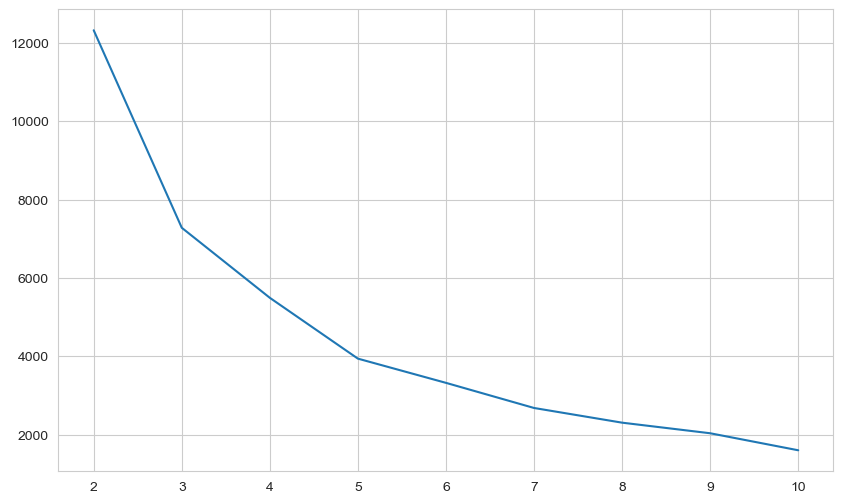

In [16]:
# TODO: Plot the elbow curve
# x-axis: k values
# y-axis: inertia

xpoints = k_range
ypoints = inertias

plt.plot(xpoints, ypoints)
plt.show()


### Silhouette Score Analysis

Calculate silhouette scores to validate cluster quality

In [25]:
# TODO: Calculate silhouette scores for k from 2 to 10
# For each k:
#   - Train KMeans
#   - Calculate silhouette_score(rfm_scaled, labels)

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled) 
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score={score:.4f}")


print("\n" + "="*80)
print("CHECKPOINT: Silhouette Scores Calculated")
print("="*80)

k=2: silhouette score=0.9148
k=3: silhouette score=0.5835
k=4: silhouette score=0.5925
k=5: silhouette score=0.6056
k=6: silhouette score=0.5895
k=7: silhouette score=0.5511
k=8: silhouette score=0.5493
k=9: silhouette score=0.5496
k=10: silhouette score=0.4960

CHECKPOINT: Silhouette Scores Calculated


C:\Users\reaga\AppData\Local\Temp\ipykernel_31496\2874268070.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


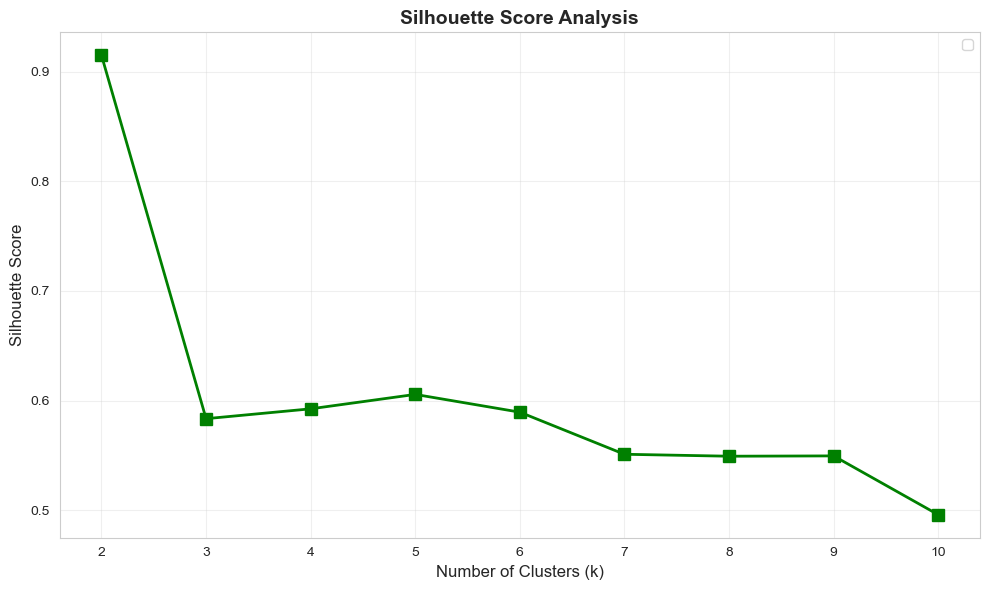

In [26]:
# TODO: Plot silhouette scores
# x-axis: k values
# y-axis: silhouette score

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Select Optimal k

**Your k selection justification (write 2-3 sentences):**

[Based on the elbow plot and silhouette scores, explain why you chose your k value. What did you observe at the elbow point? What were the silhouette scores like for different k values?]

In [28]:
# TODO: Set your chosen k value
optimal_k = 5  # Replace with your chosen k (e.g., 4, 5, or 6)

print(f"Chosen k value: {optimal_k}")

Chosen k value: 5


Based off of elbow plot and silhouette scores, I chose 5. 5 is where it starts to turn in the elbow plot, as well as for silhouette score, 5 was the second highest point. That is why I chose 5.

---
## Step 4: Train K-Means Model and Visualize Segments

### Train Final K-Means Model

In [42]:
# TODO: Train KMeans with your optimal_k and random_state=42


final_k = 5  # Adjust based on your analysis
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print(f"\nFinal clustering with k={final_k}")
print(f"Cluster sizes:")
print(rfm_df['Cluster'].value_counts().sort_index())

# Show mean RFM values per cluster to start understanding segments
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(f"\nCluster characteristics:")
print(cluster_summary)


print("\n" + "="*80)
print("CHECKPOINT: K-Means Model Trained")
print(f"Number of clusters: {final_k}")
if 'Cluster' in rfm_df.columns:
    print(f"\nCluster sizes:")
    print(rfm_df['Cluster'].value_counts().sort_index())
print("="*80)


Final clustering with k=5
Cluster sizes:
Cluster
0     351
1    1951
2    3619
3       2
4      19
Name: count, dtype: int64

Cluster characteristics:
            Recency   Frequency       Monetary
Cluster                                       
0         24.589744   37.854701   14940.314140
1        474.554075    2.547924     602.777095
2         74.085935    6.252556    1887.717571
3          0.500000  158.500000  560778.645000
4         20.842105  193.315789  119737.728000

CHECKPOINT: K-Means Model Trained
Number of clusters: 5

Cluster sizes:
Cluster
0     351
1    1951
2    3619
3       2
4      19
Name: count, dtype: int64


### Visualize Customer Segments

Create a 2D scatter plot showing Frequency vs Monetary, colored by cluster

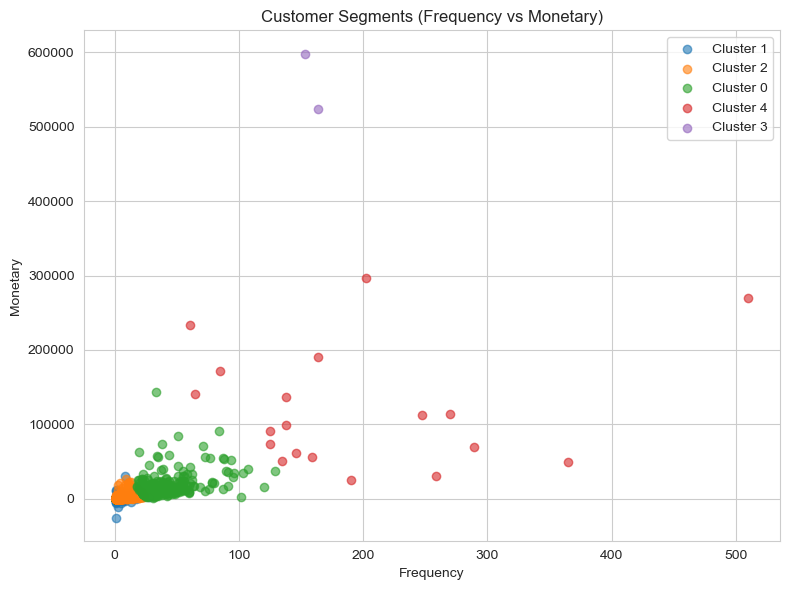

In [43]:
# TODO: Create scatter plot
# x-axis: Frequency
# y-axis: Monetary
# color: Cluster
# Include legend

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster in rfm_df['Cluster'].unique():
    subset = rfm_df[rfm_df['Cluster'] == cluster]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=f"Cluster {cluster}", alpha=0.6)

plt.title("Customer Segments (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend()
plt.tight_layout()
plt.show()

### Calculate Cluster Centers

Show the mean RFM values for each cluster

In [45]:
# TODO: Calculate mean Recency, Frequency, and Monetary for each cluster
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()  # Replace with grouped DataFrame

print(cluster_summary)

print("\n" + "="*80)
print("CLUSTER CENTERS (Mean RFM Values)")
print("="*80)
# TODO: Display cluster_summary

print("="*80)

            Recency   Frequency       Monetary
Cluster                                       
0         24.589744   37.854701   14940.314140
1        474.554075    2.547924     602.777095
2         74.085935    6.252556    1887.717571
3          0.500000  158.500000  560778.645000
4         20.842105  193.315789  119737.728000

CLUSTER CENTERS (Mean RFM Values)


---
## Step 5: Interpret Segments and Provide Business Recommendations

### Segment 0: [Descriptive Name]

**Customer Profile (3-5 sentences):**

[Describe this segment's characteristics. What are their R, F, M values? How do they differ from other segments? What business value do they represent? What are their purchasing patterns?]

In [ ]:
# TODO: Calculate detailed statistics for Segment 0
# Show mean, median, min, max for R, F, M


### Segment 1: [Descriptive Name]

**Customer Profile (3-5 sentences):**

[Describe this segment]

In [ ]:
# TODO: Calculate detailed statistics for Segment 1


### Segment 2: [Descriptive Name]

**Customer Profile (3-5 sentences):**

[Describe this segment]

In [ ]:
# TODO: Calculate detailed statistics for Segment 2


### [Continue for remaining segments]

[Add sections for Segment 3, 4, etc. depending on your chosen k]

---
## Business Recommendations

### Recommendation 1: [Title]

**Which segment(s) does this target?** [Segment name(s)]

**Recommendation (3-5 sentences):**

[Provide a specific, actionable recommendation directly tied to your cluster findings. What marketing strategy should the company implement? What channels should they use? What offers or messaging would work? Why will this work for this segment?]

### Recommendation 2: [Title]

**Which segment(s) does this target?** [Segment name(s)]

**Recommendation (3-5 sentences):**

[Your second recommendation]

### Recommendation 3: [Title]

**Which segment(s) does this target?** [Segment name(s)]

**Recommendation (3-5 sentences):**

[Your third recommendation]

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - RFM features properly calculated
   - Elbow method and silhouette score visualizations
   - Written justification for your k selection
   - Customer segment scatter plot
   - Descriptive names and profiles for each segment
   - Three specific business recommendations
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed customer segmentation assignment'
git push
```

Submit your GitHub repository link on the course platform.